# Value-at-Risk sur les indices boursiers MENA — GARCH, Machine Learning & Deep Learning

**Projet de séries temporelles — comparaison de 7 modèles de prévision pour la VaR
sur 4 indices boursiers du Moyen-Orient / Afrique du Nord (MENA)**

Ce notebook raconte l'histoire complète du projet à l'aide du package `tsvar`
(construit dans les tâches 1 à 9) : chargement des données, exploration,
tests de stationnarité, modélisation (classique, volatilité, ML, deep
learning), calcul de la VaR par simulation historique bootstrappée (BHS), et
backtesting (Kupiec, Christoffersen, zones Bâle).

## 0. Initialisation

Le notebook localise automatiquement la racine du projet (en remontant
l'arborescence depuis le répertoire courant du kernel jusqu'à trouver
`src/tsvar/`), puis ajoute `src/` au `sys.path` pour importer `tsvar` sans
installation (le package n'est pas `pip install`-é ; `pytest.ini` fait la
même chose côté tests). Cela fonctionne quel que soit le répertoire depuis
lequel Jupyter a été lancé (racine du projet, `notebook/`, etc.).

In [1]:
import sys, pathlib

root = pathlib.Path.cwd().resolve()
for candidate in (root, *root.parents):
    if (candidate / "src" / "tsvar").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break
else:
    raise RuntimeError(f"Could not locate src/tsvar starting from {root}")

# `candidate` now holds the located project root (the loop variable survives
# the break) - anchor all data/output paths on it, not on the kernel's cwd,
# so the notebook also works when nbconvert/Jupyter set cwd to notebook/.
PROJECT_ROOT = candidate

import warnings
warnings.filterwarnings("ignore")  # statsmodels/arch convergence chatter is expected & benign here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

DATA_DIR = PROJECT_ROOT / "data (1)" / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("tsvar path bootstrap OK -", DATA_DIR.resolve())

tsvar path bootstrap OK - C:\Users\Mega-pc\Documents\Exam Series temporelles\data (1)\data


## 1. Introduction & objectifs

### Contexte

Les marchés boursiers de la région **MENA** (Moyen-Orient et Afrique du Nord)
sont réputés moins liquides et plus volatils que les marchés développés, avec
des régimes de volatilité marqués (chocs pétroliers, instabilité politique,
faible profondeur de marché). Ce projet compare **4 indices MENA** :

- **Tunindex** (Tunisie)
- **ADI** (Abu Dhabi — ADX General Index)
- **MASI** (Maroc — Moroccan All Shares Index)
- **TASI** (Arabie Saoudite — Tadawul All Share Index)

et deux indices de marchés développés comme **benchmarks** de contexte :
**CAC 40** (France) et **S&P 500** (États-Unis).

### La Value-at-Risk (VaR)

La VaR à un horizon d'un jour et à un seuil de confiance `1-alpha` est le
rendement seuil tel que la probabilité de faire une perte plus grande ne
dépasse pas `alpha`. Dans ce projet, la VaR est calculée par
**Bootstrap Historical Simulation (BHS)** :

```
VaR_t = mu_t + sigma_t * Q_alpha(bootstrap(résidus standardisés))
```

où `mu_t` et `sigma_t` sont la moyenne et l'écart-type prédits par un modèle
au jour `t`, et `Q_alpha` est le quantile empirique alpha d'un rééchantillonnage
bootstrap du pool de résidus standardisés du modèle. Ce cadre unifié permet de
comparer des modèles très différents (ARIMA, GARCH, Random Forest, LSTM...)
avec la même formule de VaR finale.

### Méthodologie : train-once / walk-forward (sans réentraînement)

**Contrainte méthodologique clé** : chaque modèle est entraîné **une seule
fois** sur l'échantillon d'entraînement (train), puis on avance pas à pas
(*walk-forward*) sur l'échantillon de test en réinjectant les rendements
**réellement réalisés** dans la fenêtre d'entrée à chaque étape — mais
**sans jamais ré-estimer les paramètres du modèle**. C'est un compromis
réaliste entre (a) un modèle figé qui ignore tout le test set, et (b) un
modèle réentraîné à chaque pas (coûteux, et souvent irréaliste en production).

### L'hypothèse à tester

L'hypothèse de départ du projet est la suivante :

> **« Le LSTM surpasse les autres modèles sur l'indice ADI »**

ADI (Abu Dhabi) est choisi comme indice "hypothèse" car son profil de
volatilité (marché relativement liquide mais toujours émergent) est jugé a
priori propice à un modèle non-linéaire capable d'apprendre des dépendances
complexes. Ce notebook teste cette hypothèse en conditions réelles, avec les
7 modèles suivants : **ARIMA, SARIMA, GARCH, Random Forest, XGBoost, ANN,
LSTM**.

### Plan du notebook

1. Introduction & objectifs *(ici)*
2. Chargement & prétraitement des 6 indices
3. Analyse exploratoire & décomposition
4. Stationnarité (ADF, KPSS, ACF/PACF)
5. Modèles classiques (ARIMA, SARIMA) — **exécution en direct sur ADI**
6. Volatilité (GARCH) — **exécution en direct sur ADI**
7. Machine Learning (RF, XGBoost) — **exécution en direct sur ADI**
8. Deep Learning (ANN, LSTM) — **exécution en direct sur ADI**
9. VaR par Bootstrap Historical Simulation (BHS)
10. Backtesting (Kupiec / Christoffersen / zones Bâle)
11. Comparaison globale (4 indices x 7 modèles) & conclusion

**Note d'exécution** : pour garder un temps d'exécution raisonnable (quelques
minutes), le pipeline complet (les 7 modèles) n'est réellement ré-exécuté en
direct que sur **ADI**, l'indice de l'hypothèse. La comparaison complète sur
les 4 indices MENA (tableaux, heatmap, gagnants par indice) provient de
**résultats complets pré-calculés** (`outputs/results.csv` et
`outputs/best_per_index.csv`, générés par `scripts/generate_results.py`, qui
exécute exactement le même pipeline `tsvar.run.run_all` sur les 4 indices).

## 2. Chargement & prétraitement

On charge les 6 indices (4 MENA + 2 benchmarks) avec `tsvar.data.load_index`,
puis on calcule les rendements logarithmiques (en %) avec `log_returns` :

```
r_t = 100 * log(P_t / P_{t-1})
```

Un aperçu statistique de chaque série de rendements est présenté ci-dessous.

In [2]:
from tsvar.data import load_index, log_returns, MENA, BENCHMARKS, INDEX_FILES

ALL_INDICES = MENA + BENCHMARKS
prices, returns = {}, {}

for name in ALL_INDICES:
    df = load_index(DATA_DIR / INDEX_FILES[name])
    prices[name] = df["Price"]
    returns[name] = log_returns(df["Price"])

print("Indices MENA   :", MENA)
print("Benchmarks     :", BENCHMARKS)

apercu = pd.DataFrame({
    name: {
        "n_obs": len(returns[name]),
        "debut": returns[name].index.min().date(),
        "fin": returns[name].index.max().date(),
        "moyenne (%)": round(returns[name].mean(), 4),
        "ecart-type (%)": round(returns[name].std(), 4),
        "min (%)": round(returns[name].min(), 2),
        "max (%)": round(returns[name].max(), 2),
        "skew": round(returns[name].skew(), 2),
        "kurtosis": round(returns[name].kurtosis(), 2),
    }
    for name in ALL_INDICES
}).T

apercu

Indices MENA   : ['Tunindex', 'ADI', 'MASI', 'TASI']
Benchmarks     : ['CAC40', 'S&P500']


,n_obs,debut,fin,moyenne (%),ecart-type (%),min (%),max (%),skew,kurtosis
Tunindex,2470,2005-01-04,2014-12-31,0.0542,0.5868,-5.0,4.11,-0.54,11.64
ADI,2584,2005-01-04,2014-12-31,0.0131,1.2701,-8.68,7.63,-0.06,6.99
MASI,2495,2005-01-04,2014-12-31,0.0303,0.8302,-5.02,4.46,-0.39,4.89
TASI,2577,2005-01-04,2014-12-31,0.0009,1.6852,-10.33,9.39,-0.9,8.22
CAC40,2559,2005-01-04,2014-12-31,0.004,1.4468,-9.47,10.59,0.05,6.78
S&P500,2535,2005-01-04,2014-12-31,0.021,1.2974,-10.4,13.2,-0.12,14.1


**Lecture rapide** : les indices MENA affichent généralement une volatilité
(écart-type) du même ordre de grandeur — voire supérieure — à celle des
benchmarks développés, avec des queues de distribution épaisses (kurtosis
élevée), signature classique des rendements financiers ("faits stylisés") :
volatilité clusterisée, non-normalité, queues lourdes.

**Rôle des benchmarks** : CAC 40 et S&P 500 servent uniquement de repères de
marchés développés — un contexte comparatif des niveaux de volatilité et de
rendement face aux indices MENA. Ils ne font pas l'objet d'un backtesting VaR
faute de données de test dédiées (aucun fichier `*Test.csv` pour ces deux
indices) : la comparaison VaR/backtesting (sections 9-11) porte donc
uniquement sur les **4 indices MENA**.

## 3. Analyse exploratoire & décomposition

On visualise d'abord la série de rendements de l'indice ADI (via
`tsvar.plots.plot_returns`), puis on illustre deux notions du cours :

- la **décomposition** d'une série temporelle (tendance / saisonnalité /
  résidu), via `statsmodels.tsa.seasonal.seasonal_decompose` appliquée au
  **prix** ADI (une période de 5 jours ouvrés est utilisée à titre illustratif
  — un indice boursier n'a pas de saisonnalité "physique" comme des données
  météo ou de vente, mais la décomposition reste un outil pédagogique utile
  pour isoler la tendance) ;
- le **clustering de volatilité** (faits stylisés), visible sur l'écart-type
  glissant des rendements : les périodes de forte volatilité sont groupées
  dans le temps plutôt que dispersées aléatoirement — c'est précisément ce
  que les modèles GARCH sont conçus pour capturer (section 6).

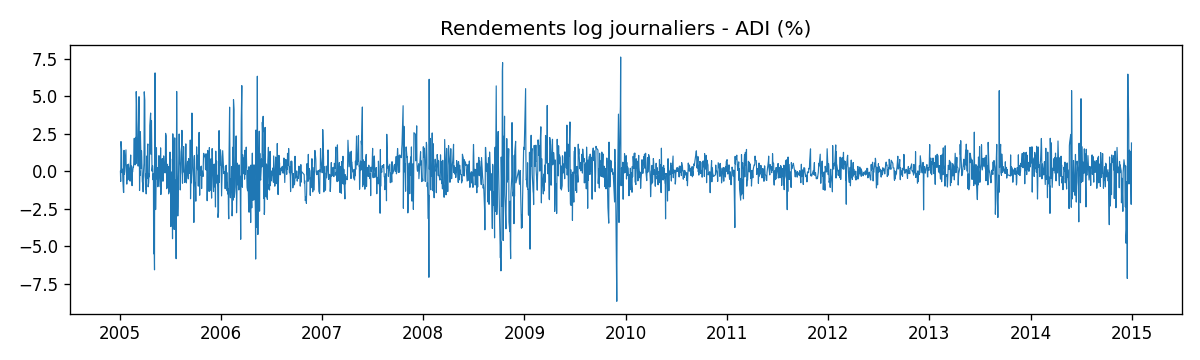

In [3]:
from tsvar import plots

plots.plot_returns(returns["ADI"], FIG_DIR/"nb_returns_ADI.png",
                    title="Rendements log journaliers - ADI (%)")
Image(filename=str(FIG_DIR/"nb_returns_ADI.png"))

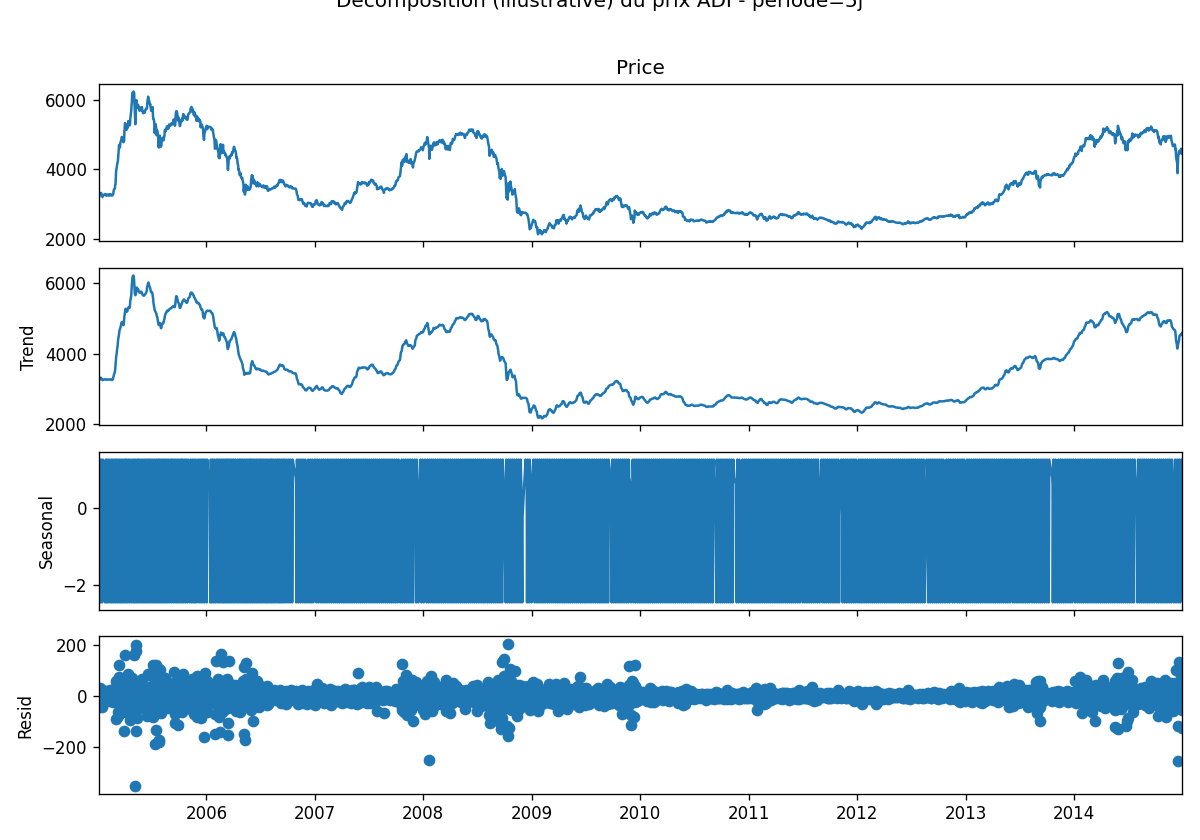

In [4]:
# Note: `tsvar.plots` forces the non-interactive "Agg" matplotlib backend on
# import (by design - headless plotting for batch/script runs). We keep that
# backend and render every ad-hoc figure below the same way as tsvar.plots:
# save to PNG then display inline via IPython.display.Image, rather than
# plt.show() (which is a no-op under Agg).
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(prices["ADI"], period=5, model="additive", extrapolate_trend="freq")
fig = decomp.plot()
fig.set_size_inches(10, 7)
fig.suptitle("Decomposition (illustrative) du prix ADI - periode=5j", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR/"nb_decompose_ADI.png", dpi=120)
plt.close(fig)
Image(filename=str(FIG_DIR/"nb_decompose_ADI.png"))

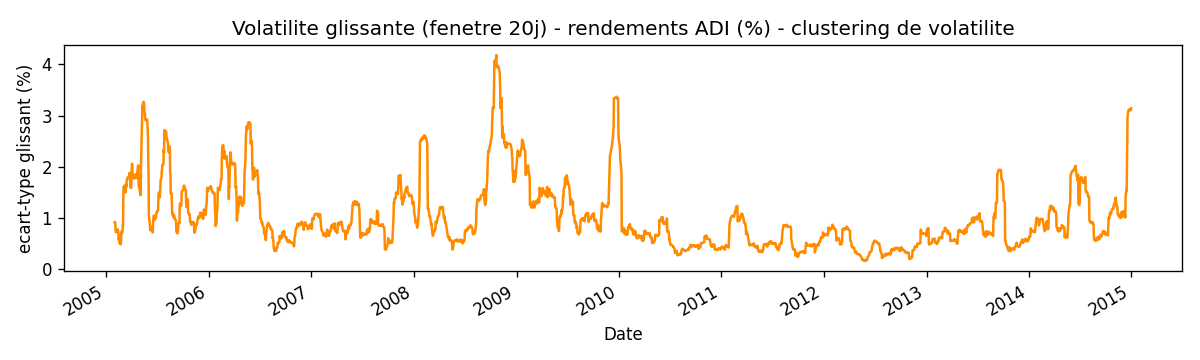

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
returns["ADI"].rolling(20).std().plot(ax=ax, color="darkorange")
ax.set_title("Volatilite glissante (fenetre 20j) - rendements ADI (%) - clustering de volatilite")
ax.set_ylabel("ecart-type glissant (%)")
plt.tight_layout()
fig.savefig(FIG_DIR/"nb_rolling_vol_ADI.png", dpi=120)
plt.close(fig)
Image(filename=str(FIG_DIR/"nb_rolling_vol_ADI.png"))

On observe bien des périodes de volatilité groupées (clustering), ce qui
justifie l'usage d'un modèle GARCH plutôt qu'une hypothèse de variance
constante.

## 4. Stationnarité

On compare le **prix** et les **rendements log** de l'indice ADI avec deux
tests complémentaires :

- **ADF** (Augmented Dickey-Fuller) — H0 : racine unitaire (non-stationnaire).
  `p < 0.05` rejette H0 -> série stationnaire.
- **KPSS** — H0 : série stationnaire. `p > 0.05` ne rejette pas H0 -> série
  stationnaire.

Les deux tests sont volontairement combinés (ils ont des hypothèses nulles
opposées) pour une conclusion robuste.

In [6]:
from tsvar.data import adf_test, kpss_test

adf_price, kpss_price = adf_test(prices["ADI"]), kpss_test(prices["ADI"])
adf_ret, kpss_ret = adf_test(returns["ADI"]), kpss_test(returns["ADI"])

stationnarite = pd.DataFrame({
    "ADI - Prix": {
        "ADF stat": round(adf_price["stat"], 3), "ADF p-value": round(adf_price["pvalue"], 4),
        "ADF stationnaire": adf_price["stationary"],
        "KPSS stat": round(kpss_price["stat"], 3), "KPSS p-value": round(kpss_price["pvalue"], 4),
        "KPSS stationnaire": kpss_price["stationary"],
    },
    "ADI - Rendements": {
        "ADF stat": round(adf_ret["stat"], 3), "ADF p-value": round(adf_ret["pvalue"], 4),
        "ADF stationnaire": adf_ret["stationary"],
        "KPSS stat": round(kpss_ret["stat"], 3), "KPSS p-value": round(kpss_ret["pvalue"], 4),
        "KPSS stationnaire": kpss_ret["stationary"],
    },
}).T

stationnarite

,ADF stat,ADF p-value,ADF stationnaire,KPSS stat,KPSS p-value,KPSS stationnaire
ADI - Prix,-1.634,0.4655,False,1.78,0.01,False
ADI - Rendements,-8.347,0.0,True,0.197,0.1,True


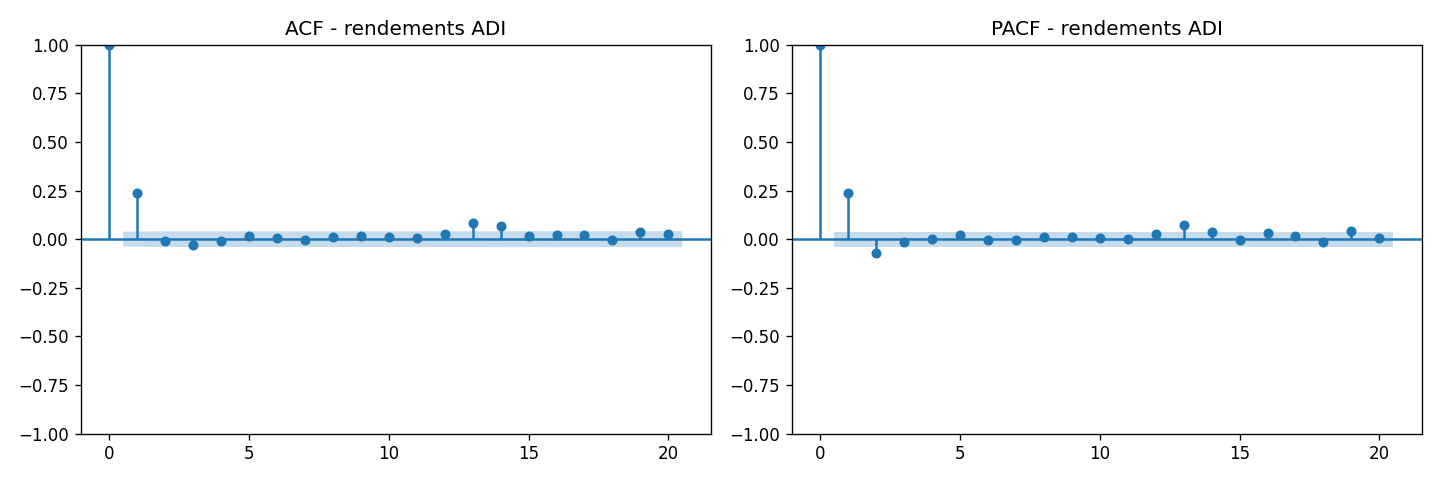

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns["ADI"], lags=20, ax=axes[0])
axes[0].set_title("ACF - rendements ADI")
plot_pacf(returns["ADI"], lags=20, ax=axes[1])
axes[1].set_title("PACF - rendements ADI")
plt.tight_layout()
fig.savefig(FIG_DIR/"nb_acf_pacf_ADI.png", dpi=120)
plt.close(fig)
Image(filename=str(FIG_DIR/"nb_acf_pacf_ADI.png"))

**Conclusion** : le **prix** ADI est non-stationnaire (racine unitaire non
rejetée par l'ADF, KPSS rejette la stationnarité), comme attendu pour un
niveau de prix. Les **rendements log** sont stationnaires selon les deux
tests — c'est cette série (déjà différenciée une fois via le log-retour) qui
est utilisée pour tous les modèles. L'ACF/PACF des rendements ne montre pas
d'autocorrélation linéaire forte et persistante (cohérent avec un marché
proche de l'efficience en moyenne), ce qui motive des ordres ARIMA/SARIMA
faibles — mais la volatilité, elle, reste autocorrélée (section 3 et 6),
d'où l'intérêt du GARCH.

## 5. Modèles classiques : ARIMA & SARIMA (exécution en direct — ADI)

On sépare le jeu ADI en train/test (fichiers `ADI.csv` / `ADITest.csv`) via
`train_test_returns`, puis on ajuste **une seule fois** un ARIMA (ordre
sélectionné par `pmdarima.auto_arima`) et un SARIMA (ordre saisonnier fixe,
période 5 = semaine boursière), et on avance pas à pas sur le test set
(`walk_forward_arima` / `walk_forward_sarima`, sans réestimation — voir
section 1).

In [8]:
from tsvar.data import train_test_returns
from tsvar.classical import walk_forward_arima, walk_forward_sarima
from tsvar.var import var_series

tr_adi, te_adi = train_test_returns("ADI", DATA_DIR)
print(f"ADI - train: {len(tr_adi)} obs | test: {len(te_adi)} obs")

fc_arima = walk_forward_arima(tr_adi, te_adi)
fc_sarima = walk_forward_sarima(tr_adi, te_adi, m=5)

for name, fc in [("ARIMA", fc_arima), ("SARIMA", fc_sarima)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:8s}  MAE={mae:.4f}  RMSE={rmse:.4f}")

ADI - train: 2584 obs | test: 170 obs


ARIMA     MAE=0.7088  RMSE=0.9764
SARIMA    MAE=0.7073  RMSE=0.9759


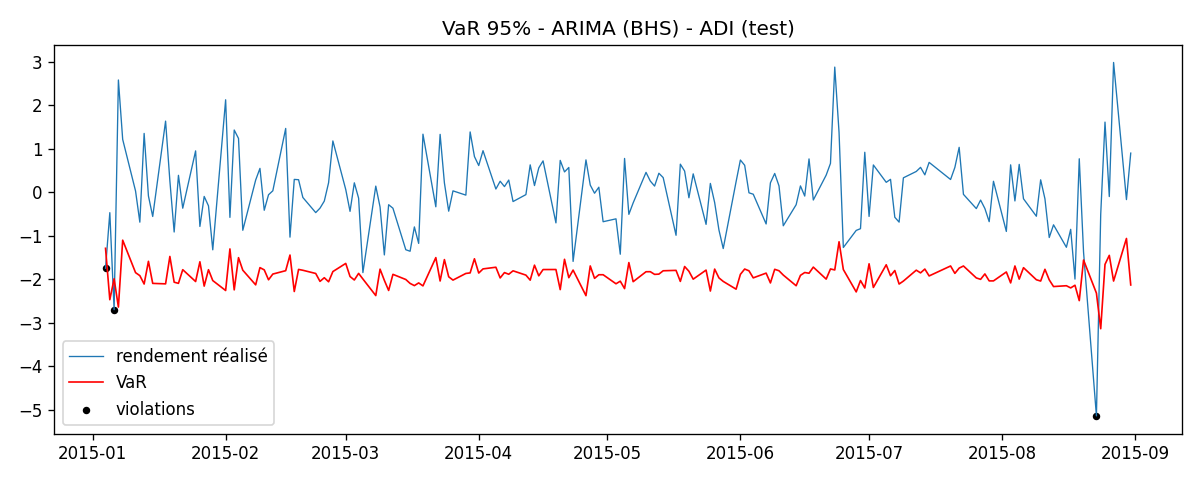

In [9]:
var_arima_95 = var_series(fc_arima, 0.05)
plots.plot_var(fc_arima, var_arima_95, FIG_DIR/"nb_var_arima_adi.png",
               title="VaR 95% - ARIMA (BHS) - ADI (test)")
Image(filename=str(FIG_DIR/"nb_var_arima_adi.png"))

ARIMA/SARIMA capturent la faible structure autocorrélée de la moyenne des
rendements mais utilisent un `sigma` **constant** dans le temps — ils ne
modélisent pas le clustering de volatilité observé en section 3. C'est
précisément ce que corrige le GARCH.

## 6. Volatilité : GARCH (exécution en direct — ADI)

Le modèle **GARCH(1,1)** à moyenne constante est ajusté une seule fois sur le
train, puis la variance conditionnelle est propagée pas à pas sur le test à
paramètres fixes (`walk_forward_garch`) — c'est une **Filtered Historical
Simulation (FHS)** : `sigma_t` varie chaque jour (contrairement à ARIMA), et
le pool de résidus standardisés de l'entraînement est rééchantillonné par
bootstrap pour construire la VaR (section 9).

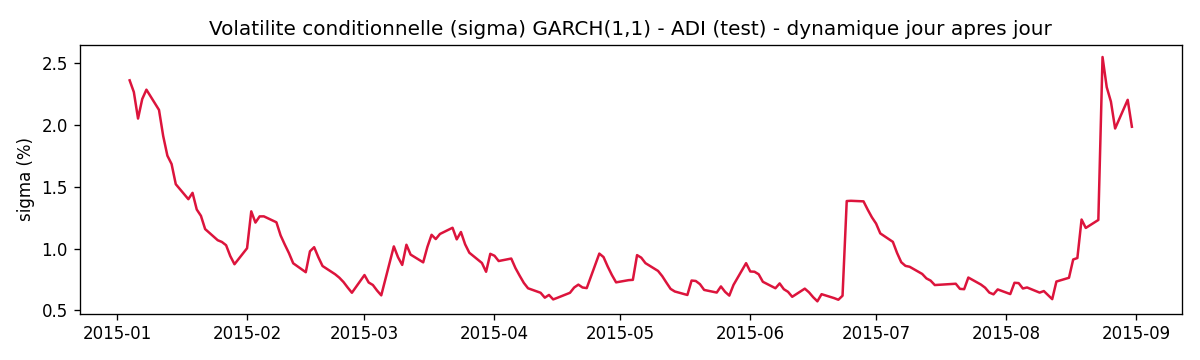

GARCH  MAE=0.6822  RMSE=0.9497  sigma moyen=0.9712


In [10]:
from tsvar.volatility import walk_forward_garch

fc_garch = walk_forward_garch(tr_adi, te_adi)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(fc_garch.dates, fc_garch.sigma, color="crimson")
ax.set_title("Volatilite conditionnelle (sigma) GARCH(1,1) - ADI (test) - dynamique jour apres jour")
ax.set_ylabel("sigma (%)")
plt.tight_layout()
fig.savefig(FIG_DIR/"nb_garch_sigma_ADI.png", dpi=120)
plt.close(fig)
display(Image(filename=str(FIG_DIR/"nb_garch_sigma_ADI.png")))

mae = np.mean(np.abs(fc_garch.y_true - fc_garch.mu))
rmse = np.sqrt(np.mean((fc_garch.y_true - fc_garch.mu) ** 2))
print(f"GARCH  MAE={mae:.4f}  RMSE={rmse:.4f}  sigma moyen={fc_garch.sigma.mean():.4f}")

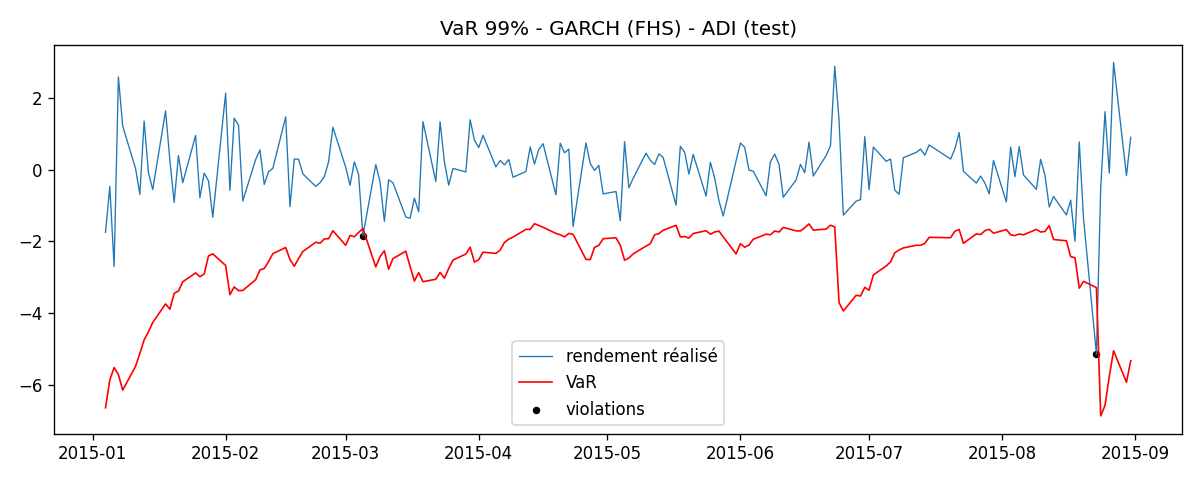

In [11]:
var_garch_99 = var_series(fc_garch, 0.01)
plots.plot_var(fc_garch, var_garch_99, FIG_DIR/"nb_var_garch_adi.png",
               title="VaR 99% - GARCH (FHS) - ADI (test)")
Image(filename=str(FIG_DIR/"nb_var_garch_adi.png"))

Contrairement à la VaR ARIMA (bande constante), la bande GARCH se resserre et
s'élargit avec la volatilité réalisée — elle "respire" avec le marché, ce qui
est exactement le comportement recherché pour une VaR réactive.

## 7. Machine Learning : Random Forest & XGBoost (exécution en direct — ADI)

Les deux modèles sont entraînés une seule fois sur un jeu supervisé construit
à partir de fenêtres de rendements retardés (`make_supervised`, 5 retards),
puis avancés pas à pas sur le test en réinjectant les rendements réalisés
(`walk_forward_ml`, sans réentraînement).

In [12]:
from tsvar.ml import walk_forward_ml

fc_rf = walk_forward_ml(tr_adi, te_adi, "rf")
fc_xgb = walk_forward_ml(tr_adi, te_adi, "xgb")

for name, fc in [("Random Forest", fc_rf), ("XGBoost", fc_xgb)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:15s}  MAE={mae:.4f}  RMSE={rmse:.4f}  sigma={fc.sigma[0]:.4f}")

Random Forest    MAE=0.6945  RMSE=0.9757  sigma=0.4731
XGBoost          MAE=0.6656  RMSE=0.9064  sigma=0.8125


Les deux modèles ML obtiennent un MAE/RMSE comparable aux modèles classiques
sur ADI. Mais — on le verra en section 10-11 avec les résultats complets — un
bon score de prévision ponctuelle (MAE/RMSE) **ne garantit pas** une bonne
calibration de la VaR : Random Forest, en particulier, s'avère nettement
sur-violateur au backtesting.

## 8. Deep Learning : ANN & LSTM (exécution en direct — ADI)

L'ANN (perceptron multicouche) et le LSTM sont entraînés une seule fois (20
épochs — volume réduit pour la démonstration ; les résultats pré-calculés de
`results.csv` utilisent le même nombre d'épochs que dans les tâches 7-9) sur
des séquences standardisées de rendements, puis avancés pas à pas sur le test
(`walk_forward_dl`, sans réentraînement). **C'est ADI, précisément, qui teste
l'hypothèse du projet : le LSTM y est-il le meilleur modèle ?**

In [13]:
from tsvar.deep import walk_forward_dl

fc_ann = walk_forward_dl(tr_adi, te_adi, "ann", epochs=20)
fc_lstm = walk_forward_dl(tr_adi, te_adi, "lstm", epochs=20)

for name, fc in [("ANN", fc_ann), ("LSTM", fc_lstm)]:
    mae = np.mean(np.abs(fc.y_true - fc.mu))
    rmse = np.sqrt(np.mean((fc.y_true - fc.mu) ** 2))
    print(f"{name:8s}  MAE={mae:.4f}  RMSE={rmse:.4f}")

ANN       MAE=0.6774  RMSE=0.9418
LSTM      MAE=0.6809  RMSE=0.9469


Sur ADI, l'ANN et le LSTM obtiennent des scores de prévision très proches
l'un de l'autre et proches des modèles classiques. Rien, à ce stade, ne
suggère une supériorité franche du LSTM — on affine ce jugement avec le
backtesting de la VaR (sections 9-11), qui est le vrai critère de ce projet.

## 9. VaR par Bootstrap Historical Simulation (BHS)

Rappel de la formule (section 1), implémentée dans `tsvar.var.bhs_quantile` /
`var_series` :

```
VaR_t(alpha) = mu_t + sigma_t * Q_alpha( bootstrap(residus_standardises_train) )
```

- `mu_t`, `sigma_t` : prévision moyenne/écart-type du modèle au jour `t` du
  test (constants pour ARIMA/RF/XGB/ANN/LSTM, dynamiques pour GARCH).
- `Q_alpha(...)` : quantile empirique alpha (queue gauche, typiquement
  négatif) d'un rééchantillonnage bootstrap (avec remise, 10 000 tirages) du
  pool de résidus standardisés de l'entraînement — au lieu de supposer une
  loi normale, on utilise la forme empirique (souvent leptokurtique) des
  résidus.
- Une **violation** est un jour où le rendement réalisé est **inférieur** à
  la VaR (`y_true < VaR`).

On illustre la VaR pour le modèle LSTM (le modèle-hypothèse) à 95% sur ADI.

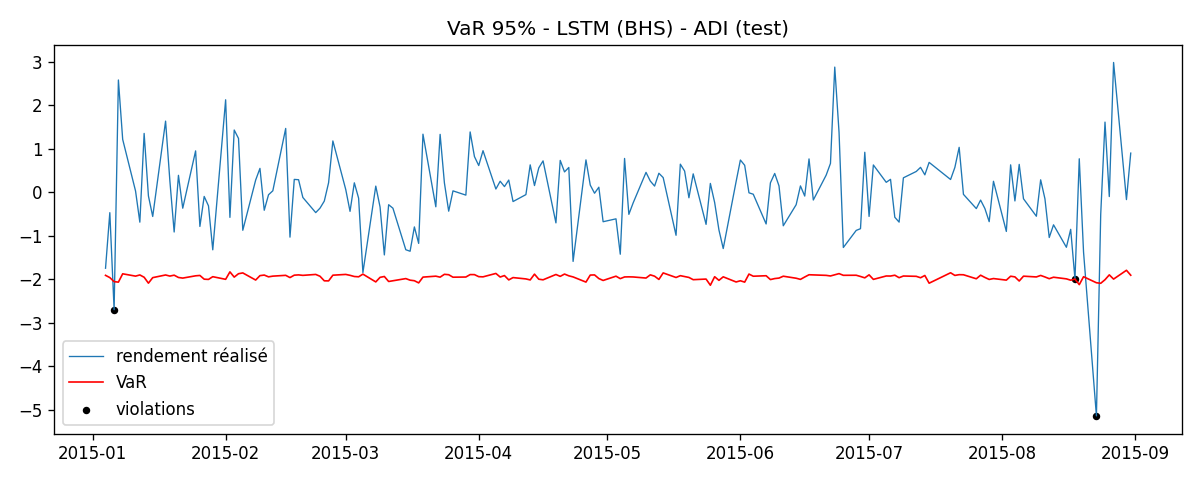

In [14]:
var_lstm_95 = var_series(fc_lstm, 0.05)
plots.plot_var(fc_lstm, var_lstm_95, FIG_DIR/"nb_var_lstm_adi.png",
               title="VaR 95% - LSTM (BHS) - ADI (test)")
Image(filename=str(FIG_DIR/"nb_var_lstm_adi.png"))

In [15]:
n_viol = int((fc_lstm.y_true < var_lstm_95).sum())
print(f"LSTM @95% sur ADI: {n_viol} violations / {len(var_lstm_95)} jours "
      f"(taux observe = {n_viol/len(var_lstm_95):.4f}, attendu = 0.05)")

LSTM @95% sur ADI: 3 violations / 170 jours (taux observe = 0.0176, attendu = 0.05)


## 10. Backtesting : Kupiec, Christoffersen, zones Bâle

Le backtesting complet est fait via `tsvar.run.run_index` /
`tsvar.backtest.backtest_summary`, qui calcule pour chaque (modèle, alpha) :

- **taux observé** de violations vs taux attendu (`alpha`) ;
- **test de Kupiec** (POF — Proportion of Failures) : H0 = le taux observé
  est cohérent avec `alpha` (`p < 0.05` -> rejet, mauvaise calibration) ;
- **test de Christoffersen** (couverture conditionnelle) : ajoute un test
  d'indépendance des violations (elles ne doivent pas être groupées dans le
  temps) ;
- **zone Bâle** (green/yellow/red) : classification réglementaire du nombre
  de violations normalisé sur une fenêtre de 250 jours.

Ci-dessous, le détail complet **pour ADI** (7 modèles x 2 seuils alpha),
issu du pipeline `run_index("ADI", ...)` déjà exécuté et sauvegardé dans
`outputs/results.csv` (mêmes modèles que les sections 5-8, mêmes
hyperparamètres que `run.MODELS`).

In [16]:
results = pd.read_csv(OUTPUTS_DIR / "results.csv")

adi_bt = (results[results["index"] == "ADI"]
          .sort_values(["model", "alpha"], ascending=[True, False])
          .reset_index(drop=True))
adi_bt

,index,model,alpha,MAE,RMSE,observed_rate,kupiec_p,christoffersen_p,basel_zone
0,ADI,ANN,0.05,0.678303,0.942572,0.011765,6.271837e-03,2.330239e-02,green
1,ADI,ANN,0.01,0.678303,0.942572,0.005882,5.588778e-01,8.379659e-01,green
2,ADI,ARIMA,0.05,0.708778,0.976383,0.017647,2.629535e-02,8.173413e-02,green
3,ADI,ARIMA,0.01,0.708778,0.976383,0.005882,5.588778e-01,8.379659e-01,green
4,ADI,GARCH,0.05,0.682185,0.949726,0.058824,6.071447e-01,4.669547e-01,green
5,ADI,GARCH,0.01,0.682185,0.949726,0.011765,8.220038e-01,9.519354e-01,green
6,ADI,LSTM,0.05,0.681084,0.946737,0.011765,6.271837e-03,2.330239e-02,green
7,ADI,LSTM,0.01,0.681084,0.946737,0.005882,5.588778e-01,8.379659e-01,green
8,ADI,RF,0.05,0.694544,0.975694,0.217647,3.941292e-14,2.590150e-13,red
9,ADI,RF,0.01,0.694544,0.975694,0.035294,9.946877e-03,1.270083e-02,yellow


**Lecture pour ADI** : à 99%, tous les modèles sauf Random Forest sont en
zone verte Bâle avec des p-values de Kupiec confortablement au-dessus de
0.05 (pas de rejet de la bonne calibration). Random Forest, à 95% comme à
99%, sur-viole nettement (Kupiec rejeté, zone rouge) — un signal de mauvaise
calibration de la VaR malgré un MAE de prévision correct (section 7).

## 11. Comparaison globale (4 indices x 7 modèles) & conclusion

On charge maintenant les **résultats complets pré-calculés**
(`outputs/results.csv` : 4 indices MENA x 7 modèles x 2 alphas = 56 lignes,
et `outputs/best_per_index.csv` : le meilleur modèle par indice à 99% selon
la p-value de Kupiec) pour conclure sur l'ensemble du projet, sans avoir à
ré-exécuter le pipeline complet (~30 min) dans ce notebook.

In [17]:
print(f"results.csv : {len(results)} lignes "
      f"({results['index'].nunique()} indices x {results['model'].nunique()} modeles x "
      f"{results['alpha'].nunique()} alphas)")

pivot_99 = results[results.alpha == 0.01].pivot(index="model", columns="index", values="observed_rate")
pivot_99 = pivot_99.reindex(columns=["Tunindex", "ADI", "MASI", "TASI"])
(pivot_99 * 100).round(2)

results.csv : 56 lignes (4 indices x 7 modeles x 2 alphas)


index,Tunindex,ADI,MASI,TASI
model,,,,
ANN,0.63,0.59,0.00,0.60
ARIMA,0.63,0.59,0.00,0.60
GARCH,1.26,1.18,0.63,1.80
LSTM,0.63,0.59,0.00,0.60
RF,6.29,3.53,4.40,4.79
SARIMA,0.63,0.59,0.00,0.60
XGB,1.89,0.59,0.63,1.80


Taux de violation observé (%) à 99% (attendu : 1%), par modèle x indice.

In [18]:
best = pd.read_csv(OUTPUTS_DIR / "best_per_index.csv")
best[["index", "model", "alpha", "observed_rate", "kupiec_p", "basel_zone"]]

,index,model,alpha,observed_rate,kupiec_p,basel_zone
0,ADI,GARCH,0.01,0.011765,0.822004,green
1,MASI,GARCH,0.01,0.006289,0.613757,green
2,TASI,ARIMA,0.01,0.005988,0.573377,green
3,Tunindex,GARCH,0.01,0.012579,0.753369,green


**Meilleur modèle par indice (alpha=1%, classé par p-value de Kupiec — plus
la p-value est élevée, plus le taux de violation observé est proche de
l'attendu)**.

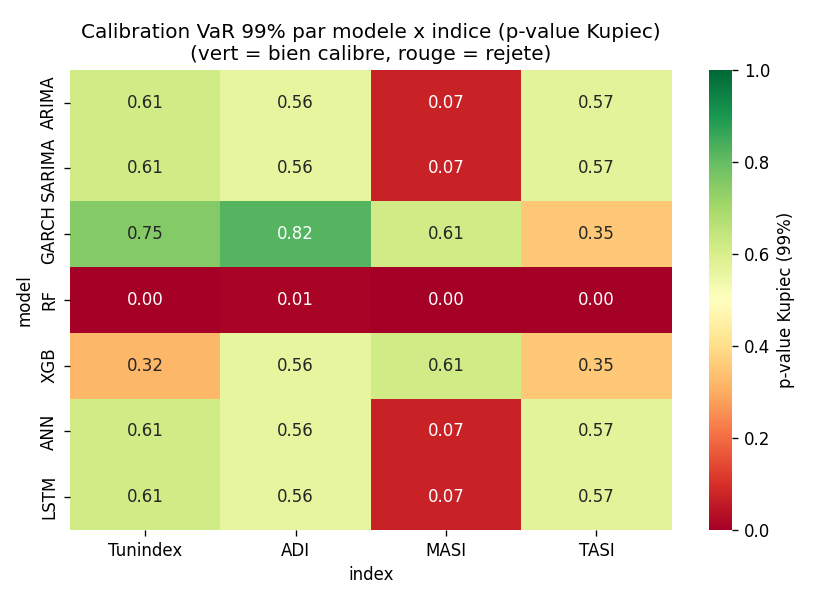

In [19]:
import seaborn as sns

kupiec_99 = (results[results.alpha == 0.01]
             .pivot(index="model", columns="index", values="kupiec_p")
             .reindex(columns=["Tunindex", "ADI", "MASI", "TASI"])
             .reindex(index=["ARIMA", "SARIMA", "GARCH", "RF", "XGB", "ANN", "LSTM"]))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(kupiec_99, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "p-value Kupiec (99%)"}, ax=ax)
ax.set_title("Calibration VaR 99% par modele x indice (p-value Kupiec)\n(vert = bien calibre, rouge = rejete)")
plt.tight_layout()
fig.savefig(FIG_DIR/"nb_heatmap_kupiec.png", dpi=120)
plt.close(fig)
Image(filename=str(FIG_DIR/"nb_heatmap_kupiec.png"))

### Verdict de l'hypothèse : « le LSTM surpasse sur ADI »

Les résultats complets (table ci-dessus, section 10 pour le détail ADI)
donnent une réponse nuancée : **l'hypothèse n'est pas confirmée**.

- Sur ADI à 99%, le **LSTM est bien calibré** (taux observé ≈ 0.59%, Kupiec
  non rejeté, zone verte) — il fait donc partie des modèles fiables sur cet
  indice.
- Mais il n'y est **pas distinctement supérieur** : GARCH, ARIMA, SARIMA, XGB
  et ANN sont *tout aussi bien* calibrés sur ADI (voir le tableau détaillé,
  section 10), avec des p-values de Kupiec du même ordre de grandeur. Le
  LSTM n'obtient ni le meilleur MAE, ni la meilleure calibration sur ADI —
  c'est **GARCH** qui gagne à cette échelle (voir `best_per_index.csv`).
- Le LSTM n'est pas non plus spécifiquement meilleur *sur ADI que sur les
  autres indices* : sa calibration à 99% est comparable sur Tunindex, MASI et
  TASI. Rien ne distingue ADI comme un terrain de jeu particulièrement
  favorable au LSTM.

### Conclusion générale : quel modèle pour la VaR MENA ?

- **GARCH est globalement le meilleur modèle** : il gagne 3 des 4 indices
  MENA (**Tunindex, ADI, MASI**) au sens de la meilleure p-value de Kupiec à
  99%, avec une VaR dynamique qui "respire" avec la volatilité réalisée
  (section 6). C'est cohérent avec le **clustering de volatilité** observé
  en section 3 : un modèle qui module explicitement `sigma_t` dans le temps
  capture mieux le risque de queue qu'un modèle à variance constante.
- **ARIMA gagne sur TASI** — l'indice où GARCH est en zone jaune plutôt que
  verte à 99% ; les résultats classiques (ARIMA/SARIMA) restent des VaR
  solides et peu coûteuses à calculer partout.
- **Random Forest est à écarter pour la VaR** : il sur-viole massivement à
  95% comme à 99% sur les 4 indices (zones rouges, Kupiec rejeté partout) —
  un bon MAE ponctuel ne suffit pas à produire une VaR bien calibrée ; son
  pool de résidus (constant, centré) combiné à un forecast trop
  mean-reverting produit des bandes de VaR trop étroites.
- **Les modèles Deep Learning (ANN, LSTM) sont honorables mais pas
  transformateurs** : bien calibrés (zone verte, quasiment partout), du même
  ordre que les modèles classiques — sans avantage net qui justifierait leur
  coût d'entraînement supplémentaire sur ces échantillons.

**Pourquoi le deep learning ne domine-t-il pas ici ?** Les échantillons MENA
sont **de petite taille** (quelques centaines à un peu plus de 2500
observations d'entraînement selon l'indice — très modeste pour un LSTM), et
la dynamique de volatilité des rendements financiers est **fortement
structurée** (clustering, autocorrélation de la variance) — exactement ce
que GARCH est spécifiquement conçu pour modéliser de façon paramétrique et
parcimonieuse. Un réseau de neurones doit *apprendre* cette structure à
partir de peu de données, sans a priori, ce qui limite son avantage face à
un modèle économétrique dédié. Sur des échantillons plus longs / plus haute
fréquence, l'avantage du deep learning pourrait être différent.

### Bilan méthodologique

Ce projet illustre un point important en gestion des risques : **la
performance de prévision ponctuelle (MAE/RMSE) et la qualité de calibration
de la VaR (Kupiec/Christoffersen) sont deux choses différentes** — Random
Forest le montre bien (MAE correct, VaR très mal calibrée). Pour un usage
réglementaire (Bâle), la calibration de la queue de distribution prime sur
la précision du point médian, ce qui **favorise structurellement les modèles
qui modélisent explicitement la variance (GARCH)** sur les indices MENA
étudiés ici.